In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [2]:
df = pd.read_csv("people.csv")
df

,satisfactoryLevel,lastEvaluation,numberOfProjects,avgMonthlyHours,timeSpent.company,workAccident,left,promotionInLast5years,dept,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.37,0.52,2,159,3,0,1,0,sales,low
4,0.41,0.50,2,153,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14994,0.11,0.85,7,275,4,0,1,0,support,medium
14995,0.99,0.83,4,274,2,0,0,0,sales,low
14996,0.72,0.72,4,175,4,0,0,0,technical,low
14997,0.24,0.91,5,177,5,0,0,0,sales,low


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfactoryLevel      14999 non-null  float64
 1   lastEvaluation         14999 non-null  float64
 2   numberOfProjects       14999 non-null  int64  
 3   avgMonthlyHours        14999 non-null  int64  
 4   timeSpent.company      14999 non-null  int64  
 5   workAccident           14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotionInLast5years  14999 non-null  int64  
 8   dept                   14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [4]:
df.isnull().sum()

satisfactoryLevel        0
lastEvaluation           0
numberOfProjects         0
avgMonthlyHours          0
timeSpent.company        0
workAccident             0
left                     0
promotionInLast5years    0
dept                     0
salary                   0
dtype: int64

In [7]:
#Rename the column timeSpent.company
df = df.rename(columns={"timeSpentcompany": "timeSpentCompany"})
df.columns

Index(['satisfactoryLevel', 'lastEvaluation', 'numberOfProjects',
       'avgMonthlyHours', 'timeSpentCompany', 'workAccident', 'left',
       'promotionInLast5years', 'dept', 'salary'],
      dtype='object')

In [8]:
df

,satisfactoryLevel,lastEvaluation,numberOfProjects,avgMonthlyHours,timeSpentCompany,workAccident,left,promotionInLast5years,dept,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.37,0.52,2,159,3,0,1,0,sales,low
4,0.41,0.50,2,153,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14994,0.11,0.85,7,275,4,0,1,0,support,medium
14995,0.99,0.83,4,274,2,0,0,0,sales,low
14996,0.72,0.72,4,175,4,0,0,0,technical,low
14997,0.24,0.91,5,177,5,0,0,0,sales,low


In [9]:
df.duplicated().sum()

np.int64(3008)

In [10]:
df = df.drop_duplicates()
df

,satisfactoryLevel,lastEvaluation,numberOfProjects,avgMonthlyHours,timeSpentCompany,workAccident,left,promotionInLast5years,dept,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.37,0.52,2,159,3,0,1,0,sales,low
4,0.41,0.50,2,153,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14992,0.30,0.88,5,245,4,0,0,0,hr,low
14995,0.99,0.83,4,274,2,0,0,0,sales,low
14996,0.72,0.72,4,175,4,0,0,0,technical,low
14997,0.24,0.91,5,177,5,0,0,0,sales,low


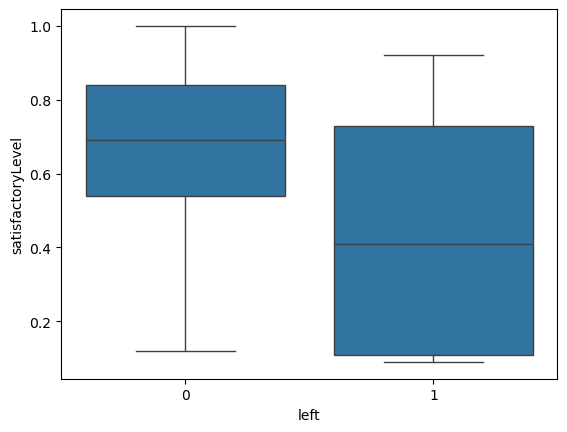

In [11]:
sns.boxplot(x = 'left', y = 'satisfactoryLevel', data = df)
plt.show()

In [12]:
pd.crosstab(df['salary'], df['left'])

left,0,1
salary,,
high,942,48
low,4566,1174
medium,4492,769


In [13]:
df['salary'].value_counts()

salary
low       5740
medium    5261
high       990
Name: count, dtype: int64

In [14]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [15]:
df['salary'] = le.fit_transform(df['salary'])

C:\Users\Shreyas_Srijith\AppData\Local\Temp\ipykernel_14744\1158406838.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['salary'] = le.fit_transform(df['salary'])


In [16]:
df['salary'].value_counts()

salary
1    5740
2    5261
0     990
Name: count, dtype: int64

In [17]:
# most of the times in le it will follow the chronological order

In [18]:
df['dept'] = le.fit_transform(df['dept'])

C:\Users\Shreyas_Srijith\AppData\Local\Temp\ipykernel_14744\2524734208.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['dept'] = le.fit_transform(df['dept'])


In [19]:
df['dept'].value_counts()

dept
7    3239
9    2244
8    1821
0     976
1     694
6     686
5     673
2     621
3     601
4     436
Name: count, dtype: int64

In [20]:
df['left'].value_counts()

left
0    10000
1     1991
Name: count, dtype: int64

In [23]:
#correlation of data
df.corr()

,satisfactoryLevel,lastEvaluation,numberOfProjects,avgMonthlyHours,timeSpentCompany,workAccident,left,promotionInLast5years,dept,salary
satisfactoryLevel,1.000000,0.095186,-0.133246,-0.006252,-0.152915,0.039940,-0.350558,0.019789,0.006941,0.007216
lastEvaluation,0.095186,1.000000,0.270256,0.264678,0.096829,-0.005695,0.013520,-0.007206,0.004309,0.007091
numberOfProjects,-0.133246,0.270256,1.000000,0.331516,0.188837,-0.005612,0.030928,-0.000544,0.010101,0.003199
avgMonthlyHours,-0.006252,0.264678,0.331516,1.000000,0.102875,-0.012860,0.070409,-0.004964,0.000623,0.002727
timeSpentCompany,-0.152915,0.096829,0.188837,0.102875,1.000000,0.000003,0.173295,0.056828,-0.017806,0.000369
workAccident,0.039940,-0.005695,-0.005612,-0.012860,0.000003,1.000000,-0.125436,0.029852,0.006560,-0.003654
left,-0.350558,0.013520,0.030928,0.070409,0.173295,-0.125436,1.000000,-0.044657,0.018286,0.004224
promotionInLast5years,0.019789,-0.007206,-0.000544,-0.004964,0.056828,0.029852,-0.044657,1.000000,-0.023826,0.004832
dept,0.006941,0.004309,0.010101,0.000623,-0.017806,0.006560,0.018286,-0.023826,1.000000,0.006702
salary,0.007216,0.007091,0.003199,0.002727,0.000369,-0.003654,0.004224,0.004832,0.006702,1.000000


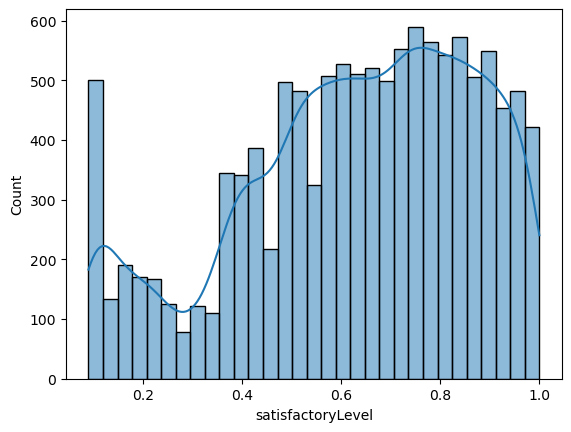

In [24]:
#Check the normal distribution of the data
sns.histplot(df['satisfactoryLevel'], kde = True)
plt.show()

In [25]:
df['satisfactoryLevel'].skew()

np.float64(-0.5387016649389444)

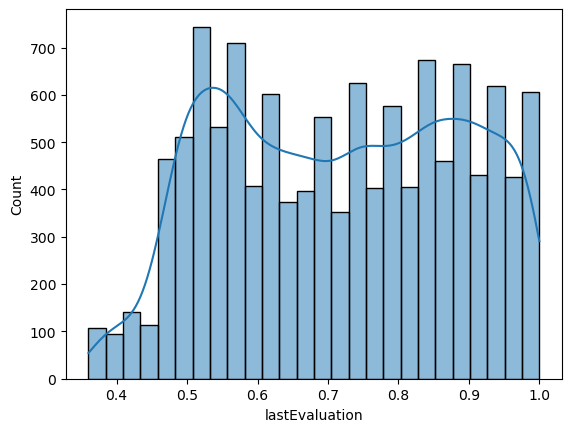

In [27]:
sns.histplot(df['lastEvaluation'], kde = True)
plt.show()

In [26]:
df['lastEvaluation'].skew()

np.float64(-0.03168607520058823)

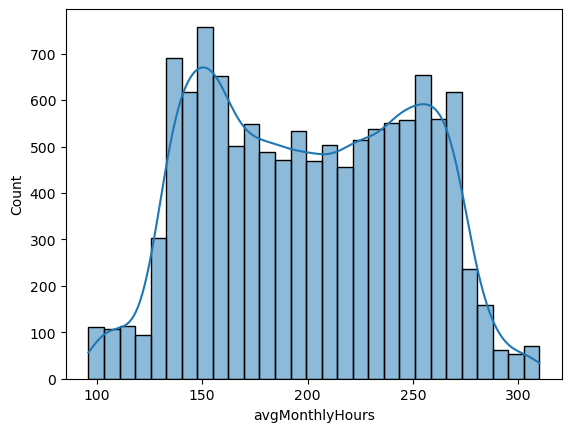

In [28]:
sns.histplot(df['avgMonthlyHours'], kde = True)
plt.show()

In [29]:
df['avgMonthlyHours'].skew()

np.float64(0.027208037002942387)

In [30]:
#Shapiro-Wilk test
# h0 -- data is normally distributed
# h1 -- data is not normally distributed

In [31]:
from scipy.stats import shapiro

In [32]:
stat, p_val = shapiro(df['satisfactoryLevel'])
print(stat, p_val)

0.9526718376165387 6.698511499093979e-52


C:\Users\Shreyas_Srijith\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 11991.
  res = hypotest_fun_out(*samples, **kwds)


In [33]:
if p_val<0.05:
  print("Reject the null hypothesis. Data is not normal")
else:
  print("Data is normally distributed")

Reject the null hypothesis. Data is not normal


In [34]:
stat, p_val = shapiro(df['avgMonthlyHours'])
print(stat, p_val)

if p_val<0.05:
  print("Reject the null hypothesis. Data is not normal")
else:
  print("Data is normally distributed")

0.9684337050832326 5.633325542635255e-45
Reject the null hypothesis. Data is not normal


In [38]:
filtered_df = df[(df['satisfactoryLevel']>=0) & (df['satisfactoryLevel']<=0.5) & (df['avgMonthlyHours'] >= 130) & (df['avgMonthlyHours'] <= 200)]
filtered_df

,satisfactoryLevel,lastEvaluation,numberOfProjects,avgMonthlyHours,timeSpentCompany,workAccident,left,promotionInLast5years,dept,salary
0,0.38,0.53,2,157,3,0,1,0,7,1
3,0.37,0.52,2,159,3,0,1,0,7,1
4,0.41,0.50,2,153,3,0,1,0,7,1
7,0.42,0.53,2,142,3,0,1,0,7,1
8,0.45,0.54,2,135,3,0,1,0,7,1
...,...,...,...,...,...,...,...,...,...,...
14900,0.45,0.46,2,142,3,0,1,0,6,1
14915,0.39,0.57,2,131,3,0,1,0,8,2
14932,0.26,0.71,6,189,2,0,0,0,5,0
14937,0.25,0.69,3,187,4,0,0,0,5,2


In [41]:
twoplus = filtered_df[filtered_df['timeSpentCompany']>2]['avgMonthlyHours']
twoplus

0        157
3        159
4        153
7        142
8        135
        ... 
14877    146
14900    142
14915    131
14937    187
14997    177
Name: avgMonthlyHours, Length: 1462, dtype: int64

In [51]:
twoyr = filtered_df[filtered_df['timeSpentCompany']==2]['avgMonthlyHours']
twoyr

35       152
379      198
413      141
1239     175
1426     182
        ... 
14685    190
14835    171
14840    156
14855    193
14932    189
Name: avgMonthlyHours, Length: 217, dtype: int64

In [52]:
# T test
# When comparing single sample with fixed value
# else if we are comparing two independent samples - ttest_ind (independent t-test)
from scipy.stats import ttest_ind
stat,pval = ttest_ind(twoyr,twoplus)
print(stat,pval)
if p_val<0.05:
  print("Reject the null hypothesis")
else:
  print("Null hypothesis is true")

8.674900266345617 9.603250154797434e-18
Reject the null hypothesis


In [53]:
twoyr.mean()

np.float64(167.2258064516129)

In [54]:
twoplus.mean()

np.float64(155.54787961696306)

In [55]:
#Z test
#For comparing percentage and proportion --two proportion zz test
from statsmodels.stats.proportion import proportions_ztest

In [56]:
twoplus = filtered_df[filtered_df['timeSpentCompany']>2]
twoplus

,satisfactoryLevel,lastEvaluation,numberOfProjects,avgMonthlyHours,timeSpentCompany,workAccident,left,promotionInLast5years,dept,salary
0,0.38,0.53,2,157,3,0,1,0,7,1
3,0.37,0.52,2,159,3,0,1,0,7,1
4,0.41,0.50,2,153,3,0,1,0,7,1
7,0.42,0.53,2,142,3,0,1,0,7,1
8,0.45,0.54,2,135,3,0,1,0,7,1
...,...,...,...,...,...,...,...,...,...,...
14877,0.45,0.47,2,146,3,0,1,0,7,2
14900,0.45,0.46,2,142,3,0,1,0,6,1
14915,0.39,0.57,2,131,3,0,1,0,8,2
14937,0.25,0.69,3,187,4,0,0,0,5,2


In [57]:
twoyr = filtered_df[filtered_df['timeSpentCompany']==2]
twoyr

,satisfactoryLevel,lastEvaluation,numberOfProjects,avgMonthlyHours,timeSpentCompany,workAccident,left,promotionInLast5years,dept,salary
35,0.13,0.78,6,152,2,0,1,0,8,1
379,0.48,0.78,2,198,2,0,1,0,9,2
413,0.34,0.67,4,141,2,0,1,0,7,1
1239,0.14,0.47,4,175,2,0,1,0,1,2
1426,0.19,0.58,5,182,2,0,0,0,9,2
...,...,...,...,...,...,...,...,...,...,...
14685,0.39,0.48,3,190,2,0,0,0,9,1
14835,0.50,0.90,4,171,2,0,0,0,3,1
14840,0.13,0.97,3,156,2,0,0,0,8,2
14855,0.45,0.41,3,193,2,1,0,0,7,1


In [58]:
# Number of ppl who have left
count = [
    twoyr['left'].sum(),
    twoplus['left'].sum()
]

# Total ppl in each group
nobs = [
    len(twoyr),
    len(twoplus)
]

In [59]:
z_stat,p_value = proportions_ztest(count,nobs)
print(z_stat,p_value)

-13.758698501260488 4.515832794128438e-43


In [60]:
if p_val<0.05:
  print("Reject the null hypothesis")
else:
  print("Null hypothesis is true")

Reject the null hypothesis


In [61]:
#Measure of Central tendency
#Measure of dispersion
df.describe()

,satisfactoryLevel,lastEvaluation,numberOfProjects,avgMonthlyHours,timeSpentCompany,workAccident,left,promotionInLast5years,dept,salary
count,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000,11991.000000
mean,0.629658,0.716683,3.802852,200.473522,3.364857,0.154282,0.166041,0.016929,5.871153,1.356184
std,0.241070,0.168343,1.163238,48.727813,1.330240,0.361234,0.372133,0.129012,2.899022,0.628071
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.480000,0.570000,3.000000,157.000000,3.000000,0.000000,0.000000,0.000000,4.000000,1.000000
50%,0.660000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000,7.000000,1.000000
75%,0.820000,0.860000,5.000000,243.000000,4.000000,0.000000,0.000000,0.000000,8.000000,2.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000,9.000000,2.000000


In [62]:
#What is the average monthly hours for each salary level
df.groupby('salary')['avgMonthlyHours'].mean()

salary
0    200.067677
1    200.439199
2    200.587341
Name: avgMonthlyHours, dtype: float64

In [63]:
#What is the average monthly hours of ppl for different projects
df.groupby('numberOfProjects')['avgMonthlyHours'].mean()

numberOfProjects
2    164.812263
3    197.337784
4    203.872456
5    209.125392
6    230.392252
7    275.620690
Name: avgMonthlyHours, dtype: float64

In [64]:
#FInd the mean average monthly hours of ppl with low satisfaction
df.groupby('satisfactoryLevel')['avgMonthlyHours'].mean()

satisfactoryLevel
0.09    274.563636
0.10    275.945813
0.11    276.563830
0.12    224.269231
0.13    195.200000
           ...    
0.96    196.815642
0.97    200.893333
0.98    199.260606
0.99    196.439490
1.00    199.240000
Name: avgMonthlyHours, Length: 92, dtype: float64

In [71]:
pd.crosstab(df['avgMonthlyHours'],df['satisfactoryLevel'])

satisfactoryLevel,0.09,0.10,0.11,0.12,0.13,0.14,0.15,0.16,0.17,0.18,...,0.91,0.92,0.93,0.94,0.95,0.96,0.97,0.98,0.99,1.00
avgMonthlyHours,,,,,,,,,,,,,,,,,,,,,
96,0,0,0,0,0,0,1,0,0,0,...,0,1,0,0,0,0,0,0,0,0
97,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,1,0
98,0,0,0,0,0,0,2,0,0,0,...,0,0,0,0,0,0,0,0,0,0
99,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
100,0,0,0,0,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
306,0,3,5,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
307,2,4,2,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
308,3,3,4,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [65]:
#Are the number of projects affecting the salary level
df.groupby('numberOfProjects')['salary'].mean()

numberOfProjects
2    1.336283
3    1.365625
4    1.357938
5    1.352888
6    1.346247
7    1.406897
Name: salary, dtype: float64

In [67]:
pd.crosstab(df['numberOfProjects'],df['salary'])

salary,0,1,2
numberOfProjects,,,
2,98,854,630
3,328,1577,1615
4,306,1754,1625
5,200,1045,988
6,56,428,342
7,2,82,61


In [68]:
#Time spent for the ppl who left
df.groupby('left')['timeSpentCompany'].mean()

left
0    3.262000
1    3.881467
Name: timeSpentCompany, dtype: float64

In [70]:
pd.crosstab(df['timeSpentCompany'],df['left'])

left,0,1
timeSpentCompany,,
2,2879,31
3,4316,874
4,1510,495
5,580,482
6,433,109
7,94,0
8,81,0
10,107,0


In [72]:
df['satisfactoryLevel'].value_counts().sort_index()

satisfactoryLevel
0.09    110
0.10    203
0.11    188
0.12     26
0.13     45
       ... 
0.96    179
0.97    150
0.98    165
0.99    157
1.00    100
Name: count, Length: 92, dtype: int64